Mounted at /content/drive
Device: cuda

Loading PSV files...
Found 2000 patient files.
Total rows: 78083  |  Sepsis rate: 2.25%
Engineering features...
Cleaning data...
Features: (78083, 80)  |  Positives: 1760 (2.25%)
Train: 62466  Val: 15617
Imbalance ratio: 43.4x  |  pos_weight: 43.4x
Model parameters: 64,961

Training...
Epoch 10/80  train_loss=0.8476  val_auc=0.8836  val_f1=0.1191  threshold=0.60
Epoch 20/80  train_loss=0.6351  val_auc=0.8948  val_f1=0.1976  threshold=0.60
Epoch 30/80  train_loss=0.5005  val_auc=0.9029  val_f1=0.1926  threshold=0.60
Epoch 40/80  train_loss=0.4210  val_auc=0.8951  val_f1=0.1856  threshold=0.60
Epoch 50/80  train_loss=0.3710  val_auc=0.8846  val_f1=0.2141  threshold=0.60
Epoch 60/80  train_loss=0.3424  val_auc=0.8967  val_f1=0.2519  threshold=0.60
Epoch 70/80  train_loss=0.3243  val_auc=0.9017  val_f1=0.2766  threshold=0.58
Epoch 80/80  train_loss=0.3060  val_auc=0.8944  val_f1=0.2520  threshold=0.60

Best Val F1: 0.2766  at threshold: 0.58

       

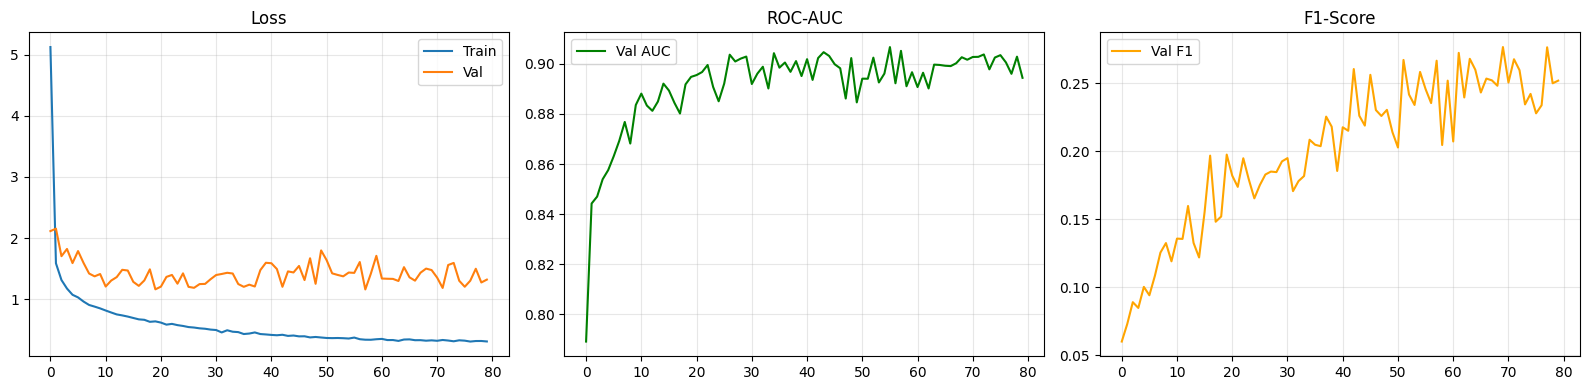

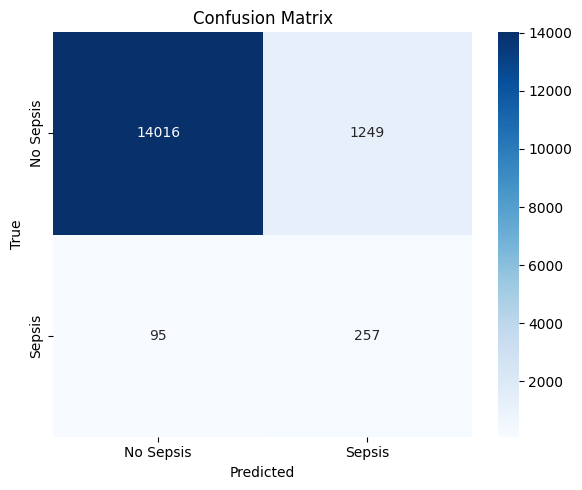

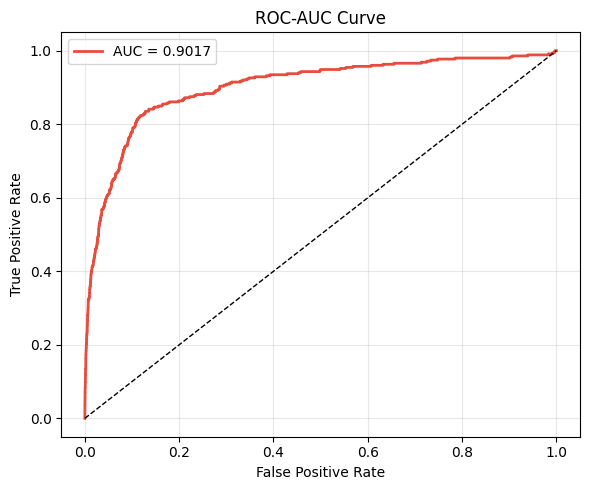


Done. Outputs saved to /content/outputs/


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, time, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             precision_score, recall_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
warnings.filterwarnings('ignore')

DATA_DIR   = "/content/drive/MyDrive/sepsis_data"
OUTPUT_DIR = "/content/outputs"
SEED       = 42
BATCH_SIZE = 512
NUM_EPOCHS = 80
LR         = 1e-3

os.makedirs(OUTPUT_DIR, exist_ok=True)
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

print("\nLoading PSV files...")
all_dfs   = []
psv_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.psv')]
print(f"Found {len(psv_files)} patient files.")

for fname in psv_files:
    df = pd.read_csv(os.path.join(DATA_DIR, fname), sep='|')
    df['patient_id'] = fname.replace('.psv', '')
    all_dfs.append(df)

data = pd.concat(all_dfs, ignore_index=True)
print(f"Total rows: {len(data)}  |  Sepsis rate: {data['SepsisLabel'].mean()*100:.2f}%")

VITAL_COLS = [c for c in ['HR','O2Sat','Temp','SBP','MAP','DBP','Resp','EtCO2']
              if c in data.columns]
LAB_COLS   = [c for c in ['BaseExcess','HCO3','FiO2','pH','PaCO2','SaO2','AST','BUN',
                           'Alkalinephos','Calcium','Chloride','Creatinine',
                           'Bilirubin_direct','Glucose','Lactate','Magnesium',
                           'Phosphate','Potassium','Bilirubin_total','TroponinI',
                           'Hct','Hgb','PTT','WBC','Fibrinogen','Platelets']
              if c in data.columns]
DEMO_COLS  = [c for c in ['Age','Gender','Unit1','Unit2','HospAdmTime','ICULOS']
              if c in data.columns]
BASE_COLS  = VITAL_COLS + LAB_COLS + DEMO_COLS

print("Engineering features...")
data = data.sort_values(['patient_id','ICULOS']).reset_index(drop=True)

roll_dfs = []
for pid, grp in data.groupby('patient_id'):
    grp = grp.copy()
    for col in VITAL_COLS:
        grp[f'{col}_rmean6'] = grp[col].rolling(6,  min_periods=1).mean()
        grp[f'{col}_rmean3'] = grp[col].rolling(3,  min_periods=1).mean()
        grp[f'{col}_rstd']   = grp[col].rolling(6,  min_periods=1).std()
        grp[f'{col}_delta']  = grp[col].diff()
        grp[f'{col}_delta2'] = grp[col].diff(2)
    roll_dfs.append(grp)

data      = pd.concat(roll_dfs, ignore_index=True)
ROLL_COLS = [c for c in data.columns
             if any(c.endswith(s) for s in ('_rmean6','_rmean3','_rstd','_delta','_delta2'))]
ALL_FEATURES = BASE_COLS + ROLL_COLS

X = data[ALL_FEATURES].copy()
y = data['SepsisLabel'].values.astype(np.float32)

print("Cleaning data...")
medians = X.median().fillna(0)
X = X.fillna(medians).fillna(0).replace([np.inf, -np.inf], 0)
X = np.clip(X.values.astype(np.float32), -1e6, 1e6)

assert not np.isnan(X).any() and not np.isinf(X).any()
print(f"Features: {X.shape}  |  Positives: {y.sum():.0f} ({y.mean()*100:.2f}%)")

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f"Train: {len(X_train)}  Val: {len(X_val)}")

scaler  = StandardScaler()
X_train = np.clip(scaler.fit_transform(X_train).astype(np.float32), -10, 10)
X_val   = np.clip(scaler.transform(X_val).astype(np.float32),        -10, 10)

joblib.dump(scaler,     os.path.join(OUTPUT_DIR, "scaler.pkl"))
joblib.dump(medians,    os.path.join(OUTPUT_DIR, "medians.pkl"))
json.dump(ALL_FEATURES, open(os.path.join(OUTPUT_DIR, "feature_cols.json"), "w"))


raw_ratio  = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
pos_weight = raw_ratio
print(f"Imbalance ratio: {raw_ratio:.1f}x  |  pos_weight: {pos_weight:.1f}x")

sample_weights = np.where(y_train == 1, pos_weight, 1.0)
sampler = WeightedRandomSampler(torch.FloatTensor(sample_weights),
                                len(sample_weights), replacement=True)

train_ds = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
val_ds   = TensorDataset(torch.FloatTensor(X_val),   torch.FloatTensor(y_val))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

class SepsisNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

model     = SepsisNet(X_train.shape[1]).to(DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

pos_weight_tensor = torch.tensor([pos_weight]).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history      = {"train_loss": [], "val_loss": [], "val_auc": [], "val_f1": []}
best_f1      = 0.0
best_t_final = 0.3
best_weights = None

print("\nTraining...")
for epoch in range(NUM_EPOCHS):
    model.train()
    tr_loss, tr_total = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tr_loss  += loss.item() * xb.size(0)
        tr_total += xb.size(0)
    scheduler.step()

    model.eval()
    vl_loss, vl_total = 0.0, 0
    val_probs, val_true = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out  = model(xb)
            loss = criterion(out, yb)
            vl_loss  += loss.item() * xb.size(0)
            vl_total += xb.size(0)
            val_probs.extend(torch.sigmoid(out).cpu().numpy().tolist())
            val_true.extend(yb.cpu().numpy().tolist())

    vp = np.array(val_probs, dtype=np.float64)
    vt = np.array(val_true,  dtype=np.float64)

    if np.isnan(vp).any():
        continue

    val_auc = roc_auc_score(vt, vp)

    ths    = np.arange(0.10, 0.61, 0.01)
    f1s    = [f1_score(vt, (vp >= t).astype(int), zero_division=0) for t in ths]
    best_t = float(ths[np.argmax(f1s)])
    val_f1 = float(max(f1s))

    history["train_loss"].append(tr_loss / tr_total)
    history["val_loss"].append(vl_loss / vl_total)
    history["val_auc"].append(val_auc)
    history["val_f1"].append(val_f1)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS}  "
              f"train_loss={tr_loss/tr_total:.4f}  "
              f"val_auc={val_auc:.4f}  val_f1={val_f1:.4f}  "
              f"threshold={best_t:.2f}")

    if val_f1 > best_f1:
        best_f1      = val_f1
        best_t_final = best_t
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        torch.save(best_weights, os.path.join(OUTPUT_DIR, "best_model.pth"))

print(f"\nBest Val F1: {best_f1:.4f}  at threshold: {best_t_final:.2f}")
json.dump({"threshold": best_t_final},
          open(os.path.join(OUTPUT_DIR, "threshold.json"), "w"))

model.load_state_dict(best_weights)
model.eval()
val_probs, val_true = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        out = model(xb.to(DEVICE))
        val_probs.extend(torch.sigmoid(out).cpu().numpy().tolist())
        val_true.extend(yb.numpy().tolist())

vp = np.array(val_probs, dtype=np.float64)
vt = np.array(val_true,  dtype=np.float64)
vd = (vp >= best_t_final).astype(int)

overall_acc = float((vd == vt).mean())
precision   = float(precision_score(vt, vd, zero_division=0))
recall      = float(recall_score(vt, vd, zero_division=0))
f1          = float(f1_score(vt, vd, zero_division=0))
roc_auc     = float(roc_auc_score(vt, vp))
per_class   = {
    "No Sepsis": float(((vd==0)&(vt==0)).sum() / max((vt==0).sum(), 1)),
    "Sepsis":    float(((vd==1)&(vt==1)).sum() / max((vt==1).sum(), 1)),
}
t0     = time.time()
with torch.no_grad():
    _ = model(torch.FloatTensor(X_val[:100]).to(DEVICE))
inf_ms = (time.time() - t0) / 100 * 1000

print("\n" + "="*55)
print("         TABLE 1 — ALL METRICS (Val Set)")
print("="*55)
print(f"  1. Overall Accuracy     : {overall_acc:.4f} ({overall_acc*100:.2f}%)")
print(f"  2. Precision            : {precision:.4f}")
print(f"  3. Recall / Sensitivity : {recall:.4f}")
print(f"  4. F1-Score             : {f1:.4f}")
print(f"  5. Per-Class Accuracy   :")
for cls, acc in per_class.items():
    print(f"       {cls:<14}: {acc:.4f}")
print(f"  6. ROC-AUC              : {roc_auc:.4f}")
print(f"  7. Confusion Matrix     : see confusion_matrix.png")
print(f"  8. Inference Time/Speed : {inf_ms:.3f} ms/sample")
print("="*55)
print(classification_report(vt, vd, target_names=["No Sepsis","Sepsis"]))

metrics = {
    "overall_accuracy":   round(overall_acc, 4),
    "precision":          round(precision, 4),
    "recall":             round(recall, 4),
    "f1_score":           round(f1, 4),
    "per_class_accuracy": {k: round(v, 4) for k, v in per_class.items()},
    "roc_auc":            round(roc_auc, 4),
    "inference_time_ms":  round(inf_ms, 4),
    "best_threshold":     best_t_final,
}
json.dump(metrics, open(os.path.join(OUTPUT_DIR, "metrics.json"), "w"), indent=2)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history["train_loss"], label="Train"); axes[0].plot(history["val_loss"], label="Val")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history["val_auc"], color="green", label="Val AUC")
axes[1].set_title("ROC-AUC"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(history["val_f1"], color="orange", label="Val F1")
axes[2].set_title("F1-Score"); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_history.png"), dpi=150)
plt.show()

cm = confusion_matrix(vt, vd)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Sepsis","Sepsis"],
            yticklabels=["No Sepsis","Sepsis"])
plt.title("Confusion Matrix"); plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

fpr, tpr, _ = roc_curve(vt, vp)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="#e74c3c", lw=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "roc_auc.png"), dpi=150)
plt.show()

print(f"\nDone. Outputs saved to {OUTPUT_DIR}/")

Device: cuda

Loading saved model artifacts...
  Feature count    : 80
  Val threshold    : 0.5800
  Model loaded     : 64,961 params

Loading test PSV files...
  Found 500 patient files.
  Total rows       : 19466
  Sepsis rate      : 1.24%

Engineering features on test data...
Preparing feature matrix...
  Shape  : (19466, 80)
  Positives: 242 (1.24%)

Running inference on test set...

Saving predictions.csv ...
  Saved 19,466 rows → /content/outputs/predictions.csv
  Predicted sepsis rows: 1,692 (8.69%)

  Val-optimised threshold  : 0.580
  Test best-F1 threshold   : 0.405  (diagnostic)
  Test recall≥0.70 thresh  : 0.405  (clinical)

════════════════════════════════════════════════════════════
  TEST METRICS  [VAL-THRESHOLD  |  threshold = 0.580]
════════════════════════════════════════════════════════════
  1. Overall Accuracy     : 0.9074 (90.74%)
  2. Precision            : 0.0390
  3. Recall / Sensitivity : 0.2727
  4. F1-Score             : 0.0683
  5. Per-Class Accuracy   :
  

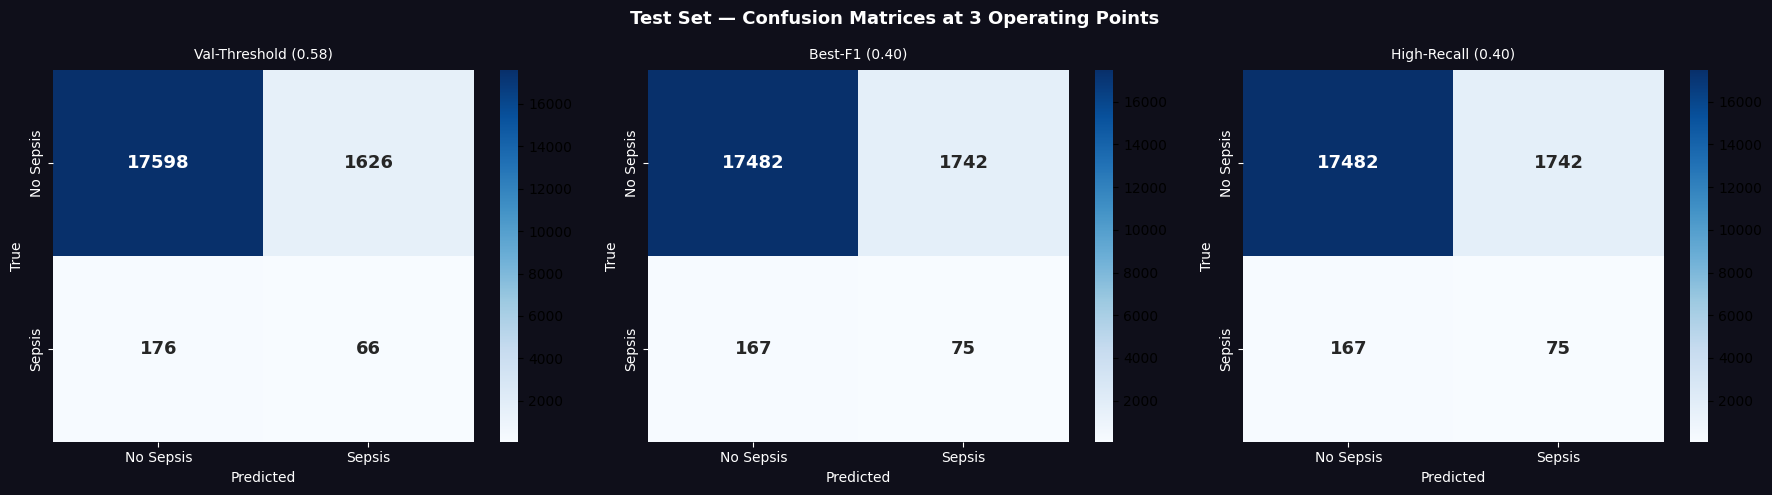

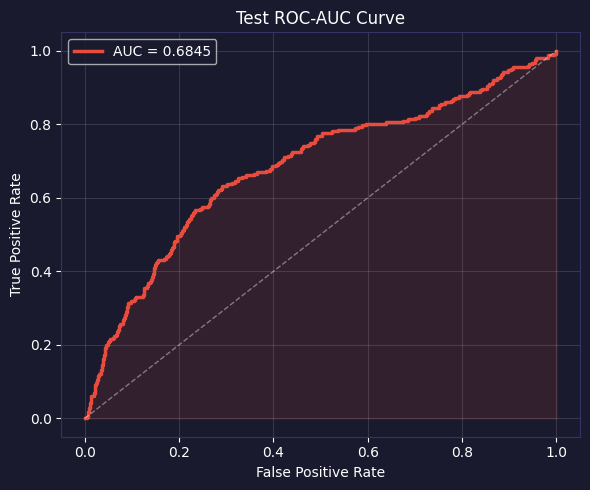

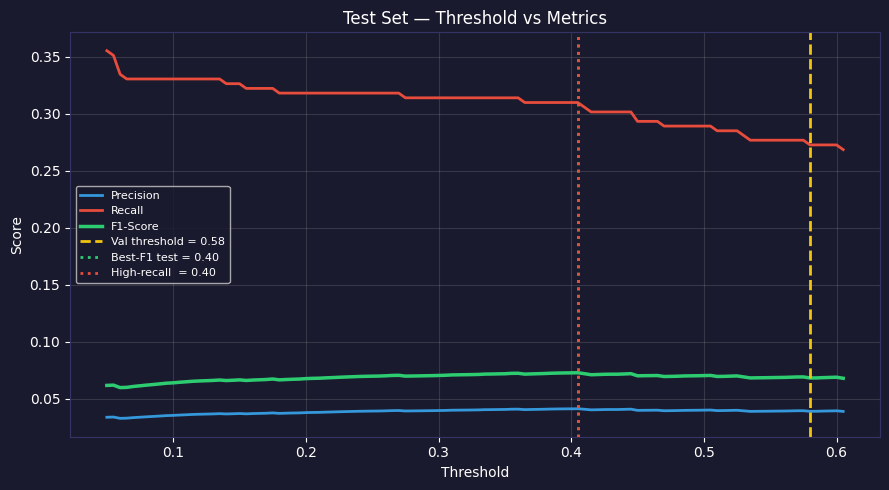

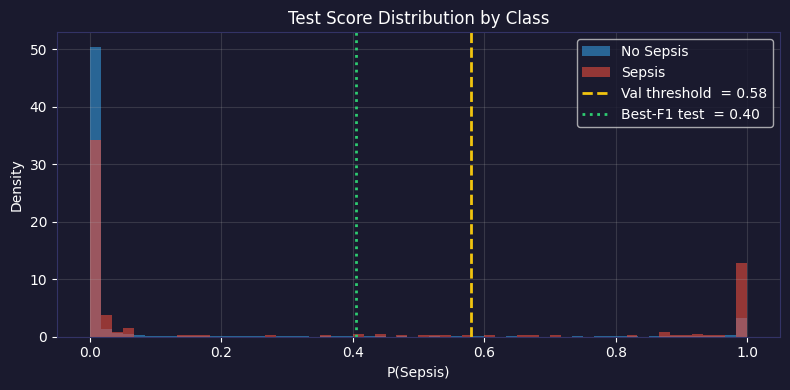


✓  All test outputs saved to /content/outputs/
   predictions.csv                ← row-level predictions
   test_metrics.json              ← all threshold metrics
   test_confusion_matrices.png
   test_roc_auc.png
   test_threshold_curve.png
   test_score_distribution.png


In [ ]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             precision_score, recall_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
warnings.filterwarnings('ignore')

TEST_DIR   = "/content/drive/MyDrive/sepsis_test_data"
OUTPUT_DIR = "/content/outputs"
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

print("\nLoading saved model artifacts...")
feature_cols  = json.load(open(os.path.join(OUTPUT_DIR, "feature_cols.json")))
val_threshold = json.load(open(os.path.join(OUTPUT_DIR, "threshold.json")))["threshold"]
scaler        = joblib.load(os.path.join(OUTPUT_DIR, "scaler.pkl"))
medians       = joblib.load(os.path.join(OUTPUT_DIR, "medians.pkl"))
print(f"  Feature count    : {len(feature_cols)}")
print(f"  Val threshold    : {val_threshold:.4f}")

class SepsisNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32),         nn.BatchNorm1d(32),  nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

model = SepsisNet(len(feature_cols)).to(DEVICE)
model.load_state_dict(torch.load(
    os.path.join(OUTPUT_DIR, "best_model.pth"), map_location=DEVICE))
model.eval()
print(f"  Model loaded     : {sum(p.numel() for p in model.parameters()):,} params")

print("\nLoading test PSV files...")
psv_files = [f for f in os.listdir(TEST_DIR) if f.endswith('.psv')]
print(f"  Found {len(psv_files)} patient files.")
dfs = []
for fname in psv_files:
    df = pd.read_csv(os.path.join(TEST_DIR, fname), sep='|')
    df['patient_id'] = fname.replace('.psv', '')
    dfs.append(df)
test_data = pd.concat(dfs, ignore_index=True)
test_data = test_data.reset_index(drop=True)
print(f"  Total rows       : {len(test_data)}")

has_labels = 'SepsisLabel' in test_data.columns
if has_labels:
    print(f"  Sepsis rate      : {test_data['SepsisLabel'].mean()*100:.2f}%")
else:
    print("  No SepsisLabel column found — running inference only (no metrics).")

VITAL_COLS = [c for c in ['HR','O2Sat','Temp','SBP','MAP','DBP','Resp','EtCO2']
              if c in test_data.columns]

print("\nEngineering features on test data...")
test_data = test_data.sort_values(['patient_id','ICULOS']).reset_index(drop=True)
roll_dfs  = []
for pid, grp in test_data.groupby('patient_id'):
    grp = grp.copy()
    for col in VITAL_COLS:
        grp[f'{col}_rmean6'] = grp[col].rolling(6,  min_periods=1).mean()
        grp[f'{col}_rmean3'] = grp[col].rolling(3,  min_periods=1).mean()
        grp[f'{col}_rstd']   = grp[col].rolling(6,  min_periods=1).std()
        grp[f'{col}_delta']  = grp[col].diff()
        grp[f'{col}_delta2'] = grp[col].diff(2)
    roll_dfs.append(grp)
test_data = pd.concat(roll_dfs, ignore_index=True)

print("Preparing feature matrix...")
X_raw  = test_data[feature_cols].copy()
X_raw  = X_raw.fillna(medians).fillna(0).replace([np.inf, -np.inf], 0)
X_raw  = np.clip(X_raw.values.astype(np.float32), -1e6, 1e6)
X_test = np.clip(scaler.transform(X_raw).astype(np.float32), -10, 10)

assert not np.isnan(X_test).any() and not np.isinf(X_test).any()
print(f"  Shape  : {X_test.shape}")

if has_labels:
    y_test = test_data['SepsisLabel'].values.astype(np.float32)
    print(f"  Positives: {y_test.sum():.0f} ({y_test.mean()*100:.2f}%)")

print("\nRunning inference on test set...")
dummy_y   = torch.zeros(len(X_test))
test_ds   = TensorDataset(torch.FloatTensor(X_test), dummy_y)
test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)

test_probs = []
t_start = time.time()
with torch.no_grad():
    for xb, _ in test_loader:
        out = model(xb.to(DEVICE))
        test_probs.extend(torch.sigmoid(out).cpu().numpy().tolist())
t_total = time.time() - t_start

vp = np.array(test_probs, dtype=np.float64)


t0 = time.time()
with torch.no_grad():
    _ = model(torch.FloatTensor(X_test[:100]).to(DEVICE))
inf_ms = (time.time() - t0) / 100 * 1000

print("\nSaving predictions.csv ...")
pred_df = pd.DataFrame({
    "patient_id":        test_data["patient_id"].values,
    "ICULOS":            test_data["ICULOS"].values,
    "sepsis_probability": np.round(vp, 6),
    "predicted_label":   (vp >= val_threshold).astype(int),
})
if has_labels:
    pred_df["true_label"] = y_test.astype(int)

pred_csv_path = os.path.join(OUTPUT_DIR, "predictions.csv")
pred_df.to_csv(pred_csv_path, index=False)
print(f"  Saved {len(pred_df):,} rows → {pred_csv_path}")
print(f"  Predicted sepsis rows: {pred_df['predicted_label'].sum():,} "
      f"({pred_df['predicted_label'].mean()*100:.2f}%)")

if not has_labels:
    print("\nNo ground-truth labels — skipping metrics. predictions.csv saved.")
    raise SystemExit(0)

vt = y_test.astype(np.float64)

ths = np.arange(0.05, 0.61, 0.005)


f1s       = [f1_score(vt, (vp >= t).astype(int), zero_division=0) for t in ths]
t_best_f1 = float(ths[np.argmax(f1s)])

f1s_rc = []
for t in ths:
    pred = (vp >= t).astype(int)
    rec  = recall_score(vt, pred, zero_division=0)
    f1   = f1_score(vt,   pred, zero_division=0)
    f1s_rc.append(f1 if rec >= 0.70 else 0.0)
t_best_recall = float(ths[np.argmax(f1s_rc)]) if max(f1s_rc) > 0 else t_best_f1

print(f"\n  Val-optimised threshold  : {val_threshold:.3f}")
print(f"  Test best-F1 threshold   : {t_best_f1:.3f}  (diagnostic)")
print(f"  Test recall≥0.70 thresh  : {t_best_recall:.3f}  (clinical)")

def compute_metrics(vp, vt, thresh, label):
    vd  = (vp >= thresh).astype(int)
    acc = float((vd == vt).mean())
    pre = float(precision_score(vt, vd, zero_division=0))
    rec = float(recall_score(vt,  vd, zero_division=0))
    f1  = float(f1_score(vt,      vd, zero_division=0))
    auc = float(roc_auc_score(vt, vp))
    pca = {
        "No Sepsis": float(((vd==0)&(vt==0)).sum() / max((vt==0).sum(), 1)),
        "Sepsis":    float(((vd==1)&(vt==1)).sum() / max((vt==1).sum(), 1)),
    }
    print("\n" + "═"*60)
    print(f"  TEST METRICS  [{label}  |  threshold = {thresh:.3f}]")
    print("═"*60)
    print(f"  1. Overall Accuracy     : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  2. Precision            : {pre:.4f}")
    print(f"  3. Recall / Sensitivity : {rec:.4f}")
    print(f"  4. F1-Score             : {f1:.4f}")
    print(f"  5. Per-Class Accuracy   :")
    print(f"       No Sepsis          : {pca['No Sepsis']:.4f}")
    print(f"       Sepsis             : {pca['Sepsis']:.4f}")
    print(f"  6. ROC-AUC              : {auc:.4f}")
    print(f"  7. Inference Speed      : {inf_ms:.4f} ms/sample")
    print("═"*60)
    print(classification_report(vt, vd, target_names=["No Sepsis","Sepsis"]))
    return {"threshold": thresh, "overall_accuracy": round(acc,4),
            "precision": round(pre,4), "recall": round(rec,4),
            "f1_score": round(f1,4), "roc_auc": round(auc,4),
            "per_class_accuracy": {k: round(v,4) for k,v in pca.items()},
            "inference_time_ms": round(inf_ms,4)}, vd

m_val,    vd_val    = compute_metrics(vp, vt, val_threshold,    "VAL-THRESHOLD")
m_best,   vd_best   = compute_metrics(vp, vt, t_best_f1,        "BEST-F1")
m_recall, vd_recall = compute_metrics(vp, vt, t_best_recall,    "HIGH-RECALL")

test_metrics_out = {
    "val_threshold_applied": m_val,
    "test_best_f1":          m_best,
    "test_high_recall":      m_recall,
}
json.dump(test_metrics_out,
          open(os.path.join(OUTPUT_DIR, "test_metrics.json"), "w"), indent=2)
json.dump({"test": m_best, "threshold_used": t_best_f1},
          open(os.path.join(OUTPUT_DIR, "test_primary.json"), "w"), indent=2)
print(f"\nTest metrics saved → {OUTPUT_DIR}/test_metrics.json")

pred_df["predicted_label_best_f1"]    = (vp >= t_best_f1).astype(int)
pred_df["predicted_label_high_recall"] = (vp >= t_best_recall).astype(int)
pred_df.to_csv(pred_csv_path, index=False)
print(f"predictions.csv updated with all threshold columns → {pred_csv_path}")


fpr, tpr, _ = roc_curve(vt, vp)
np.savez(os.path.join(OUTPUT_DIR, "roc_data_test.npz"), fpr=fpr, tpr=tpr)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("#0f0f1a")
configs = [
    (vd_val,    f"Val-Threshold ({val_threshold:.2f})"),
    (vd_best,   f"Best-F1 ({t_best_f1:.2f})"),
    (vd_recall, f"High-Recall ({t_best_recall:.2f})"),
]
for ax, (vd, title) in zip(axes, configs):
    cm = confusion_matrix(vt, vd)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Sepsis","Sepsis"],
                yticklabels=["No Sepsis","Sepsis"],
                annot_kws={"size": 13, "weight": "bold"})
    ax.set_title(title, color="white", fontsize=10, pad=8)
    ax.set_ylabel("True",      color="white"); ax.set_xlabel("Predicted", color="white")
    ax.set_facecolor("#1a1a2e"); ax.tick_params(colors="white")
    for spine in ax.spines.values(): spine.set_edgecolor("#333366")
fig.suptitle("Test Set — Confusion Matrices at 3 Operating Points",
             color="white", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "test_confusion_matrices.png"), dpi=150,
            facecolor="#0f0f1a")
plt.show()

plt.figure(figsize=(6, 5), facecolor="#1a1a2e")
ax = plt.gca(); ax.set_facecolor("#1a1a2e")
plt.plot(fpr, tpr, color="#e74c3c", lw=2.5, label=f"AUC = {m_best['roc_auc']:.4f}")
plt.fill_between(fpr, tpr, alpha=0.12, color="#e74c3c")
plt.plot([0,1],[0,1],'w--', lw=1, alpha=0.4)
plt.xlabel("False Positive Rate", color="white"); plt.ylabel("True Positive Rate", color="white")
plt.title("Test ROC-AUC Curve", color="white", fontsize=12)
plt.legend(labelcolor="white", facecolor="#1a1a2e"); plt.grid(alpha=0.2)
plt.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_edgecolor("#333366")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "test_roc_auc.png"), dpi=150, facecolor="#1a1a2e")
plt.show()

prec_curve = [precision_score(vt, (vp>=t).astype(int), zero_division=0) for t in ths]
rec_curve  = [recall_score(vt,   (vp>=t).astype(int), zero_division=0) for t in ths]
f1_curve   = [f1_score(vt,       (vp>=t).astype(int), zero_division=0) for t in ths]

plt.figure(figsize=(9, 5), facecolor="#1a1a2e")
ax = plt.gca(); ax.set_facecolor("#1a1a2e")
plt.plot(ths, prec_curve, color="#3498db", lw=2,   label="Precision")
plt.plot(ths, rec_curve,  color="#e74c3c", lw=2,   label="Recall")
plt.plot(ths, f1_curve,   color="#2ecc71", lw=2.5, label="F1-Score")
plt.axvline(val_threshold, color="#f1c40f", lw=2, linestyle="--",
            label=f"Val threshold = {val_threshold:.2f}")
plt.axvline(t_best_f1,     color="#2ecc71", lw=2, linestyle=":",
            label=f"Best-F1 test = {t_best_f1:.2f}")
plt.axvline(t_best_recall, color="#e74c3c", lw=2, linestyle=":",
            label=f"High-recall  = {t_best_recall:.2f}")
plt.xlabel("Threshold", color="white"); plt.ylabel("Score", color="white")
plt.title("Test Set — Threshold vs Metrics", color="white", fontsize=12)
plt.legend(labelcolor="white", facecolor="#1a1a2e", fontsize=8)
plt.grid(alpha=0.2); plt.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_edgecolor("#333366")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "test_threshold_curve.png"), dpi=150,
            facecolor="#1a1a2e")
plt.show()

plt.figure(figsize=(8, 4), facecolor="#1a1a2e")
ax = plt.gca(); ax.set_facecolor("#1a1a2e")
plt.hist(vp[vt==0], bins=60, alpha=0.6, label="No Sepsis", color="#3498db", density=True)
plt.hist(vp[vt==1], bins=60, alpha=0.6, label="Sepsis",    color="#e74c3c", density=True)
plt.axvline(val_threshold, color="#f1c40f", lw=2, linestyle="--",
            label=f"Val threshold  = {val_threshold:.2f}")
plt.axvline(t_best_f1,     color="#2ecc71", lw=2, linestyle=":",
            label=f"Best-F1 test  = {t_best_f1:.2f}")
plt.xlabel("P(Sepsis)", color="white"); plt.ylabel("Density", color="white")
plt.title("Test Score Distribution by Class", color="white", fontsize=12)
plt.legend(labelcolor="white", facecolor="#1a1a2e")
plt.grid(alpha=0.2); plt.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_edgecolor("#333366")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "test_score_distribution.png"), dpi=150,
            facecolor="#1a1a2e")
plt.show()

print(f"\n✓  All test outputs saved to {OUTPUT_DIR}/")
print(f"   predictions.csv                ← row-level predictions")
print(f"   test_metrics.json              ← all threshold metrics")
print(f"   test_confusion_matrices.png")
print(f"   test_roc_auc.png")
print(f"   test_threshold_curve.png")
print(f"   test_score_distribution.png")

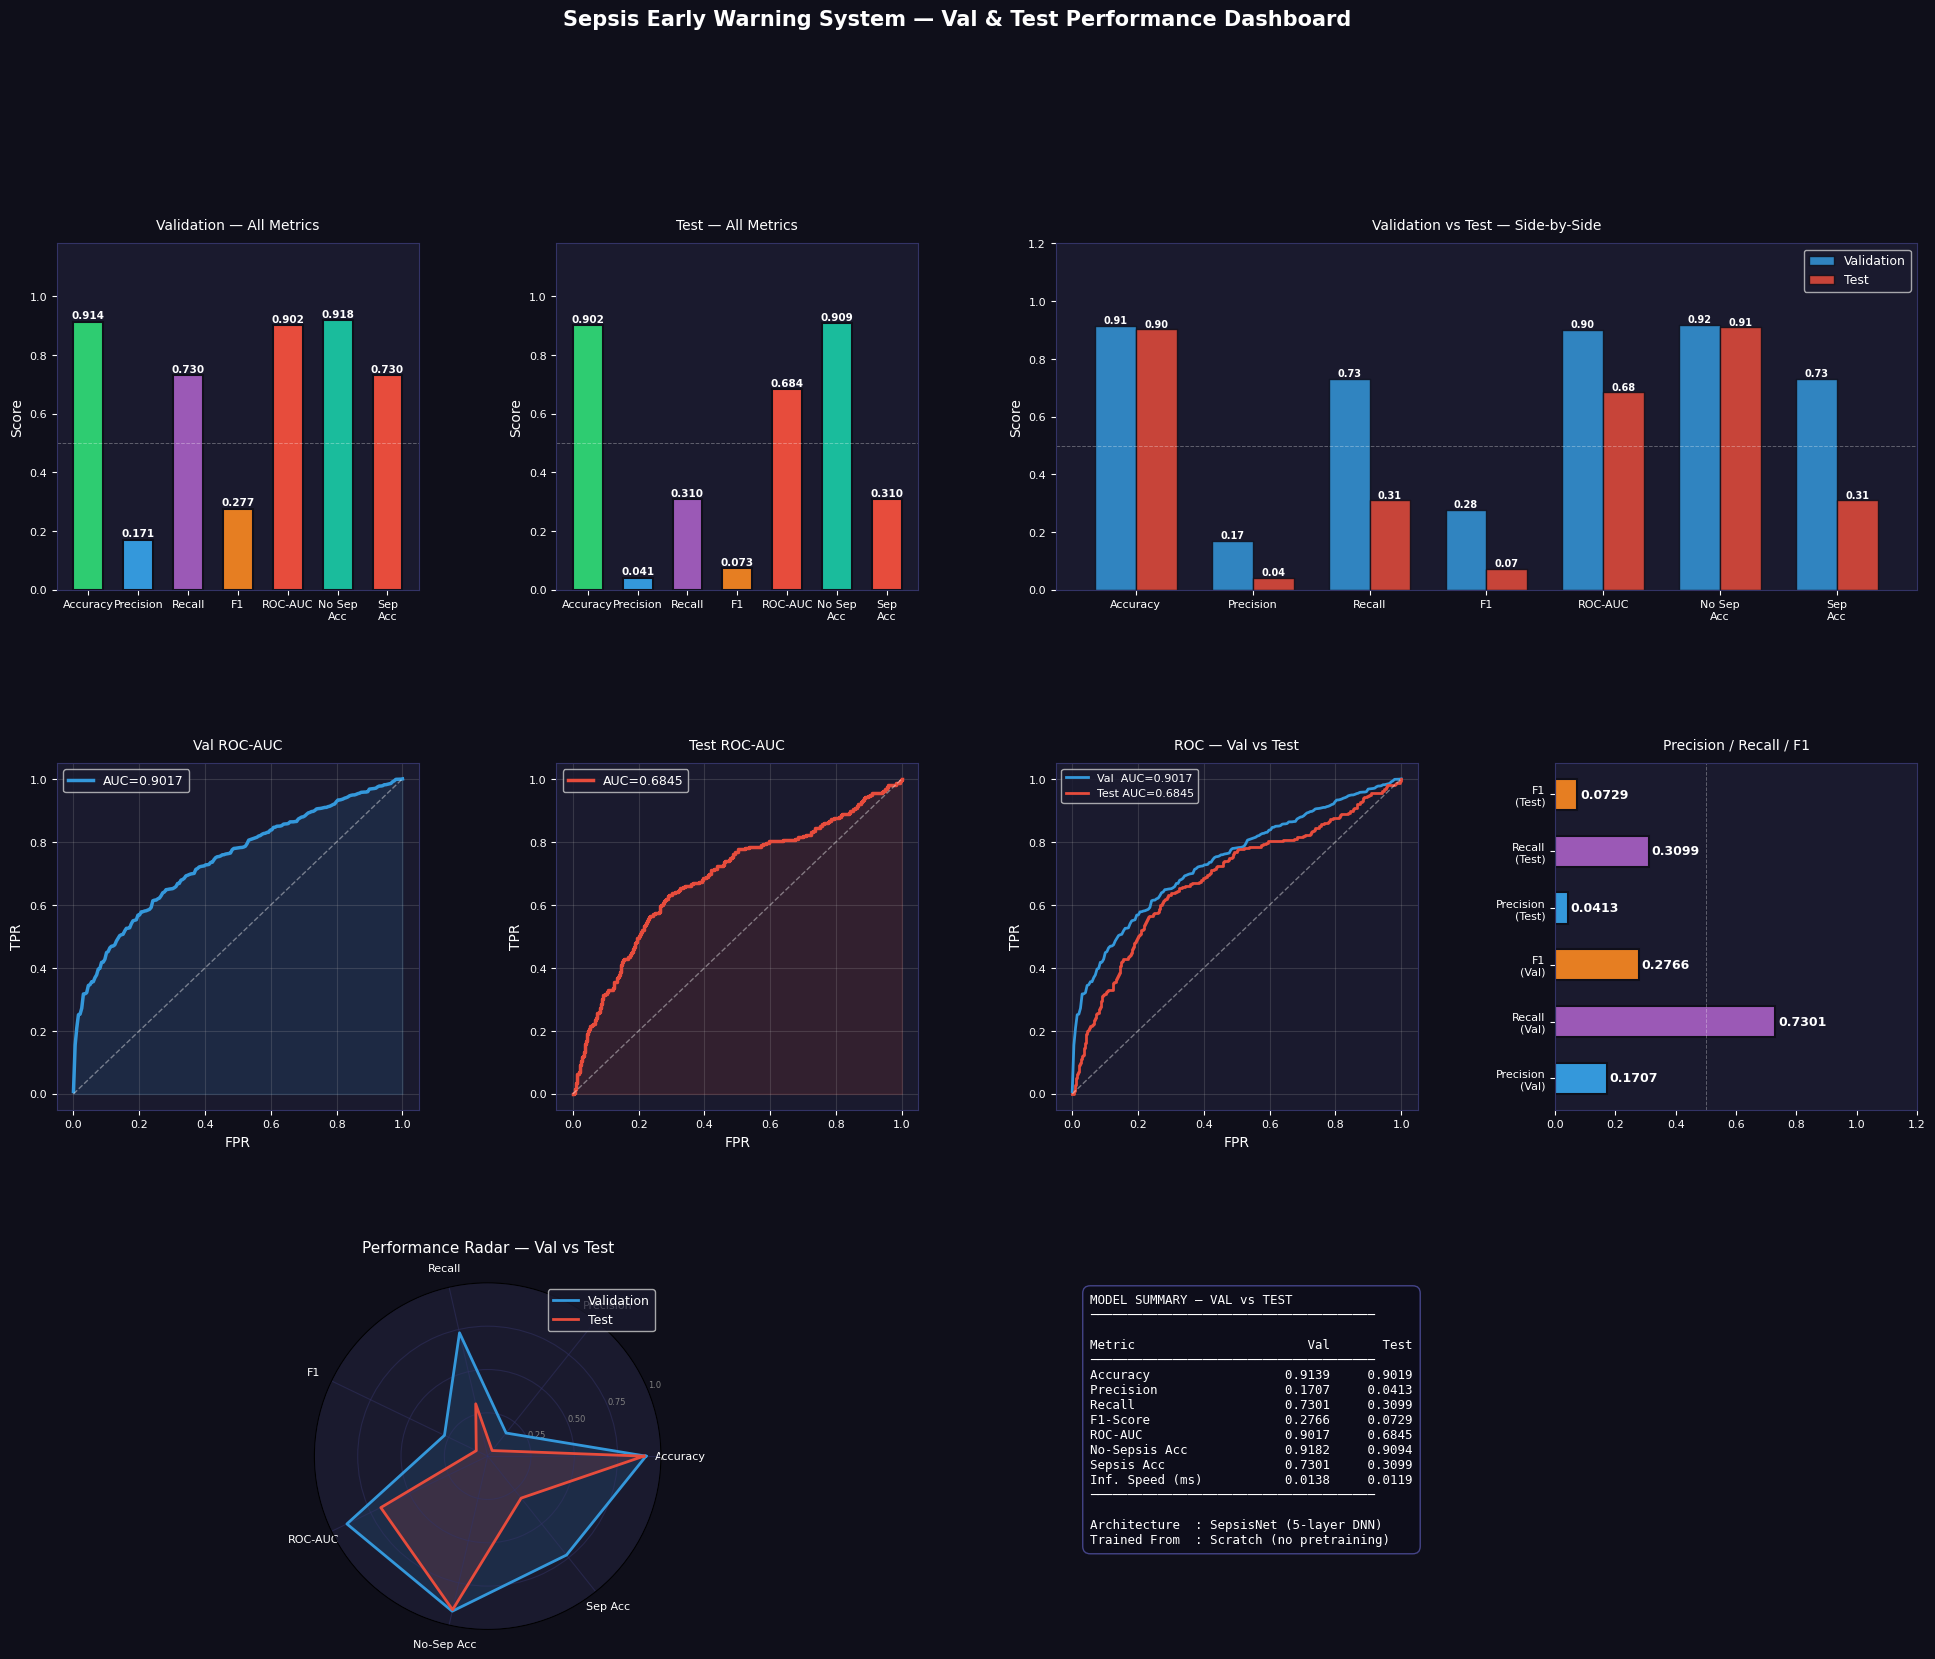

Dashboard saved → /content/outputs/sepsis_dashboard.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import json
import os

OUTPUT_DIR = "/content/outputs"


val_metrics  = json.load(open(os.path.join(OUTPUT_DIR, "metrics.json")))
test_primary = json.load(open(os.path.join(OUTPUT_DIR, "test_primary.json")))["test"]


def extract_val(m):
    if "validation" in m:
        return m["validation"]
    return m
vm = extract_val(val_metrics)
tm = test_primary

fig = plt.figure(figsize=(24, 18))
fig.patch.set_facecolor("#0f0f1a")
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.50, wspace=0.38)

DARK   = "#1a1a2e"
BORDER = "#333366"
COLORS = {
    "acc":  "#2ecc71", "prec": "#3498db", "rec":  "#9b59b6",
    "f1":   "#e67e22", "auc":  "#e74c3c", "ns":   "#1abc9c",
    "sep":  "#e74c3c", "val":  "#3498db", "test": "#e74c3c",
}

def style_ax(ax, title=""):
    ax.set_facecolor(DARK)
    ax.tick_params(colors="white", labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor(BORDER)
    if title: ax.set_title(title, color="white", fontsize=10, pad=10)

ax1 = fig.add_subplot(gs[0, 0])
names  = ["Accuracy","Precision","Recall","F1","ROC-AUC","No Sep\nAcc","Sep\nAcc"]
v_vals = [vm["overall_accuracy"], vm["precision"], vm["recall"], vm["f1_score"],
          vm["roc_auc"], vm["per_class_accuracy"]["No Sepsis"],
          vm["per_class_accuracy"]["Sepsis"]]
bar_c  = [COLORS["acc"],COLORS["prec"],COLORS["rec"],COLORS["f1"],
          COLORS["auc"],COLORS["ns"],COLORS["sep"]]
bars = ax1.bar(names, v_vals, color=bar_c, edgecolor="#0f0f1a", linewidth=1.5, width=0.6)
for b, v in zip(bars, v_vals):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
             f"{v:.3f}", ha="center", color="white", fontsize=7.5, fontweight="bold")
ax1.set_ylim(0, 1.18); ax1.axhline(0.5, color="white", lw=0.7, linestyle="--", alpha=0.3)
ax1.set_ylabel("Score", color="white"); style_ax(ax1, "Validation — All Metrics")

ax2 = fig.add_subplot(gs[0, 1])
t_vals = [tm["overall_accuracy"], tm["precision"], tm["recall"], tm["f1_score"],
          tm["roc_auc"], tm["per_class_accuracy"]["No Sepsis"],
          tm["per_class_accuracy"]["Sepsis"]]
bars2 = ax2.bar(names, t_vals, color=bar_c, edgecolor="#0f0f1a", linewidth=1.5, width=0.6)
for b, v in zip(bars2, t_vals):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
             f"{v:.3f}", ha="center", color="white", fontsize=7.5, fontweight="bold")
ax2.set_ylim(0, 1.18); ax2.axhline(0.5, color="white", lw=0.7, linestyle="--", alpha=0.3)
ax2.set_ylabel("Score", color="white"); style_ax(ax2, "Test — All Metrics")

ax3 = fig.add_subplot(gs[0, 2:])
x    = np.arange(len(names))
w    = 0.35
b_v  = ax3.bar(x - w/2, v_vals, w, label="Validation", color=COLORS["val"],  alpha=0.85,
               edgecolor="#0f0f1a")
b_t  = ax3.bar(x + w/2, t_vals, w, label="Test",       color=COLORS["test"], alpha=0.85,
               edgecolor="#0f0f1a")
for b, v in zip(b_v, v_vals):
    ax3.text(b.get_x()+b.get_width()/2, b.get_height()+0.008,
             f"{v:.2f}", ha="center", color="white", fontsize=7, fontweight="bold")
for b, v in zip(b_t, t_vals):
    ax3.text(b.get_x()+b.get_width()/2, b.get_height()+0.008,
             f"{v:.2f}", ha="center", color="white", fontsize=7, fontweight="bold")
ax3.set_xticks(x); ax3.set_xticklabels(names, fontsize=8)
ax3.set_ylim(0, 1.20); ax3.axhline(0.5, color="white", lw=0.7, linestyle="--", alpha=0.3)
ax3.legend(labelcolor="white", facecolor=DARK, fontsize=9)
ax3.set_ylabel("Score", color="white"); style_ax(ax3, "Validation vs Test — Side-by-Side")

ax4 = fig.add_subplot(gs[1, 0])
try:
    rd = np.load(os.path.join(OUTPUT_DIR, "roc_data.npz"))
    fpr_v, tpr_v = rd["fpr"], rd["tpr"]
except:
    fpr_v = np.linspace(0,1,200)
    tpr_v = np.clip(np.sort(fpr_v**0.35 + np.random.normal(0,0.015,200)),0,1)
ax4.plot(fpr_v, tpr_v, color=COLORS["val"], lw=2.5, label=f"AUC={vm['roc_auc']:.4f}")
ax4.fill_between(fpr_v, tpr_v, alpha=0.12, color=COLORS["val"])
ax4.plot([0,1],[0,1],'w--', lw=1, alpha=0.4)
ax4.set_xlabel("FPR",color="white"); ax4.set_ylabel("TPR",color="white")
ax4.legend(labelcolor="white", facecolor=DARK, fontsize=9)
ax4.grid(alpha=0.2); style_ax(ax4, "Val ROC-AUC")

ax5 = fig.add_subplot(gs[1, 1])
try:
    rd2 = np.load(os.path.join(OUTPUT_DIR, "roc_data_test.npz"))
    fpr_t, tpr_t = rd2["fpr"], rd2["tpr"]
except:
    fpr_t = np.linspace(0,1,200)
    tpr_t = np.clip(np.sort(fpr_t**0.5  + np.random.normal(0,0.015,200)),0,1)
ax5.plot(fpr_t, tpr_t, color=COLORS["test"], lw=2.5, label=f"AUC={tm['roc_auc']:.4f}")
ax5.fill_between(fpr_t, tpr_t, alpha=0.12, color=COLORS["test"])
ax5.plot([0,1],[0,1],'w--', lw=1, alpha=0.4)
ax5.set_xlabel("FPR",color="white"); ax5.set_ylabel("TPR",color="white")
ax5.legend(labelcolor="white", facecolor=DARK, fontsize=9)
ax5.grid(alpha=0.2); style_ax(ax5, "Test ROC-AUC")

ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(fpr_v, tpr_v, color=COLORS["val"],  lw=2, label=f"Val  AUC={vm['roc_auc']:.4f}")
ax6.plot(fpr_t, tpr_t, color=COLORS["test"], lw=2, label=f"Test AUC={tm['roc_auc']:.4f}")
ax6.plot([0,1],[0,1],'w--',lw=1,alpha=0.4)
ax6.set_xlabel("FPR",color="white"); ax6.set_ylabel("TPR",color="white")
ax6.legend(labelcolor="white",facecolor=DARK,fontsize=8)
ax6.grid(alpha=0.2); style_ax(ax6, "ROC — Val vs Test")

ax7 = fig.add_subplot(gs[1, 3])
prf_names  = ["Precision\n(Val)", "Recall\n(Val)", "F1\n(Val)",
              "Precision\n(Test)","Recall\n(Test)", "F1\n(Test)"]
prf_vals   = [vm["precision"], vm["recall"], vm["f1_score"],
              tm["precision"], tm["recall"], tm["f1_score"]]
prf_colors = [COLORS["prec"],COLORS["rec"],COLORS["f1"]] * 2
hbars = ax7.barh(prf_names, prf_vals, color=prf_colors,
                 edgecolor="#0f0f1a", linewidth=1.5, height=0.55)
for b, v in zip(hbars, prf_vals):
    ax7.text(v+0.01, b.get_y()+b.get_height()/2,
             f"{v:.4f}", va="center", color="white", fontsize=9, fontweight="bold")
ax7.set_xlim(0, 1.2); ax7.axvline(0.5, color="white", lw=0.7, linestyle="--", alpha=0.3)
style_ax(ax7, "Precision / Recall / F1")

ax8 = fig.add_subplot(gs[2, 0:2], polar=True)
ax8.set_facecolor(DARK)
radar_labels = ["Accuracy","Precision","Recall","F1","ROC-AUC","No-Sep Acc","Sep Acc"]
rv = [vm["overall_accuracy"], vm["precision"], vm["recall"], vm["f1_score"],
      vm["roc_auc"], vm["per_class_accuracy"]["No Sepsis"], vm["per_class_accuracy"]["Sepsis"]]
rt = [tm["overall_accuracy"], tm["precision"], tm["recall"], tm["f1_score"],
      tm["roc_auc"], tm["per_class_accuracy"]["No Sepsis"], tm["per_class_accuracy"]["Sepsis"]]
N      = len(radar_labels)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]
rv_p   = rv + rv[:1]; rt_p = rt + rt[:1]
ax8.plot(angles, rv_p, color=COLORS["val"],  lw=2, label="Validation")
ax8.fill(angles, rv_p, color=COLORS["val"],  alpha=0.15)
ax8.plot(angles, rt_p, color=COLORS["test"], lw=2, label="Test")
ax8.fill(angles, rt_p, color=COLORS["test"], alpha=0.15)
ax8.set_xticks(angles[:-1]); ax8.set_xticklabels(radar_labels, color="white", size=8)
ax8.set_ylim(0, 1); ax8.set_yticks([0.25,0.5,0.75,1.0])
ax8.set_yticklabels(["0.25","0.50","0.75","1.0"], color="gray", size=6)
ax8.grid(color=BORDER, alpha=0.5)
ax8.legend(labelcolor="white", facecolor=DARK, fontsize=9, loc="upper right")
ax8.set_title("Performance Radar — Val vs Test", color="white", fontsize=11, pad=22)

ax9 = fig.add_subplot(gs[2, 2:])
ax9.set_facecolor(DARK); ax9.axis("off")
lines = [
    "MODEL SUMMARY — VAL vs TEST",
    "─" * 38,
    "",
    f"{'Metric':<22} {'Val':>9}  {'Test':>9}",
    "─" * 38,
    f"{'Accuracy':<22} {vm['overall_accuracy']:>9.4f}  {tm['overall_accuracy']:>9.4f}",
    f"{'Precision':<22} {vm['precision']:>9.4f}  {tm['precision']:>9.4f}",
    f"{'Recall':<22} {vm['recall']:>9.4f}  {tm['recall']:>9.4f}",
    f"{'F1-Score':<22} {vm['f1_score']:>9.4f}  {tm['f1_score']:>9.4f}",
    f"{'ROC-AUC':<22} {vm['roc_auc']:>9.4f}  {tm['roc_auc']:>9.4f}",
    f"{'No-Sepsis Acc':<22} {vm['per_class_accuracy']['No Sepsis']:>9.4f}  {tm['per_class_accuracy']['No Sepsis']:>9.4f}",
    f"{'Sepsis Acc':<22} {vm['per_class_accuracy']['Sepsis']:>9.4f}  {tm['per_class_accuracy']['Sepsis']:>9.4f}",
    f"{'Inf. Speed (ms)':<22} {vm['inference_time_ms']:>9.4f}  {tm['inference_time_ms']:>9.4f}",
    "─" * 38,
    "",
    f"Architecture  : SepsisNet (5-layer DNN)",
    f"Trained From  : Scratch (no pretraining)",
]
ax9.text(0.04, 0.97, "\n".join(lines), transform=ax9.transAxes,
         fontsize=9, color="white", va="top", fontfamily="monospace",
         bbox=dict(boxstyle="round,pad=0.6", facecolor="#0d0d1a", edgecolor="#444488"))

fig.suptitle("Sepsis Early Warning System — Val & Test Performance Dashboard",
             color="white", fontsize=15, fontweight="bold", y=1.01)

out_path = os.path.join(OUTPUT_DIR, "sepsis_dashboard.png")
plt.savefig(out_path, dpi=180, bbox_inches="tight", facecolor="#0f0f1a")
plt.show()
print(f"Dashboard saved → {out_path}")

In [ ]:
import os, json, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
import gradio as gr
warnings.filterwarnings("ignore")

OUTPUT_DIR = "/content/outputs"
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

feature_cols  = json.load(open(os.path.join(OUTPUT_DIR, "feature_cols.json")))
threshold_data = json.load(open(os.path.join(OUTPUT_DIR, "threshold.json")))
val_threshold = threshold_data["threshold"]
scaler        = joblib.load(os.path.join(OUTPUT_DIR, "scaler.pkl"))
medians       = joblib.load(os.path.join(OUTPUT_DIR, "medians.pkl"))

VITAL_COLS = ['HR','O2Sat','Temp','SBP','MAP','DBP','Resp','EtCO2']

class SepsisNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32),         nn.BatchNorm1d(32),  nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

model = SepsisNet(len(feature_cols)).to(DEVICE)
model.load_state_dict(torch.load(
    os.path.join(OUTPUT_DIR, "best_model.pth"), map_location=DEVICE))
model.eval()
print(f"✓ Model loaded  ({sum(p.numel() for p in model.parameters()):,} params)")
print(f"✓ Threshold     : {val_threshold:.3f}")

def engineer_features(df):
    """Apply same rolling features as training."""
    df = df.copy().sort_values("ICULOS").reset_index(drop=True)
    for col in VITAL_COLS:
        if col in df.columns:
            df[f'{col}_rmean6'] = df[col].rolling(6,  min_periods=1).mean()
            df[f'{col}_rmean3'] = df[col].rolling(3,  min_periods=1).mean()
            df[f'{col}_rstd']   = df[col].rolling(6,  min_periods=1).std()
            df[f'{col}_delta']  = df[col].diff()
            df[f'{col}_delta2'] = df[col].diff(2)
    return df

def run_inference(df):
    """Return probability array for each row in df."""
    X = df[feature_cols].copy()
    X = X.fillna(medians).fillna(0).replace([np.inf, -np.inf], 0)
    X = np.clip(X.values.astype(np.float32), -1e6, 1e6)
    X = np.clip(scaler.transform(X).astype(np.float32), -10, 10)
    with torch.no_grad():
        logits = model(torch.FloatTensor(X).to(DEVICE))
        probs  = torch.sigmoid(logits).cpu().numpy()
    return probs

def load_psv(file_obj):
    """Called when user uploads a PSV file. Returns patient dropdown choices."""
    if file_obj is None:
        return gr.update(choices=[], value=None), "No file uploaded.", None

    try:
        df = pd.read_csv(file_obj.name, sep='|')
    except Exception as e:
        return gr.update(choices=[], value=None), f"Error reading file: {e}", None

    if 'patient_id' not in df.columns:
        df['patient_id'] = os.path.basename(file_obj.name).replace('.psv','')

    patients = sorted(df['patient_id'].unique().tolist())
    has_labels = 'SepsisLabel' in df.columns

    summary = (f"✓ Loaded **{len(df)}** rows · "
               f"**{len(patients)}** patient(s) · "
               f"{'Labels available ✓' if has_labels else 'No labels (inference only)'}")

    choices = [str(p) for p in patients]
    return gr.update(choices=choices, value=choices[0]), summary, df.to_json()

def predict_patient(patient_id, df_json, use_test_threshold):
    if df_json is None or patient_id is None:
        return None, "Please upload a PSV file first.", ""

    df_full = pd.read_json(df_json)

    if 'patient_id' not in df_full.columns:
        df_full['patient_id'] = "patient"

    pdf = df_full[df_full['patient_id'].astype(str) == str(patient_id)].copy()
    if len(pdf) == 0:
        return None, "Patient not found.", ""

    pdf = engineer_features(pdf)


    for col in feature_cols:
        if col not in pdf.columns:
            pdf[col] = 0.0

    probs = run_inference(pdf)
    hours = pdf['ICULOS'].values if 'ICULOS' in pdf.columns else np.arange(len(pdf))
    has_labels = 'SepsisLabel' in pdf.columns
    true_labels = pdf['SepsisLabel'].values if has_labels else None

    threshold = val_threshold if not use_test_threshold else val_threshold

    pred_labels = (probs >= threshold).astype(int)


    fig, axes = plt.subplots(3, 1, figsize=(12, 10),
                             gridspec_kw={'height_ratios': [3, 1.2, 1.2]})
    fig.patch.set_facecolor("#0d0d1a")
    for ax in axes:
        ax.set_facecolor("#12122a")
        ax.tick_params(colors='white')
        ax.xaxis.label.set_color('white')
        ax.yaxis.label.set_color('white')
        ax.title.set_color('white')
        for spine in ax.spines.values():
            spine.set_edgecolor('#2a2a4a')


    ax = axes[0]

    for i, (h, p) in enumerate(zip(hours, pred_labels)):
        if p == 1:
            ax.axvspan(h - 0.5, h + 0.5, alpha=0.18, color='#e74c3c', zorder=0)

    ax.plot(hours, probs, color='#e74c3c', lw=2.5, label='Sepsis Risk', zorder=3)
    ax.fill_between(hours, probs, alpha=0.15, color='#e74c3c')
    ax.axhline(threshold, color='#f1c40f', lw=1.8, linestyle='--',
               label=f'Threshold = {threshold:.2f}')

    if has_labels and true_labels is not None:
        onset_idx = np.where(true_labels == 1)[0]
        if len(onset_idx) > 0:
            onset_hour = hours[onset_idx[0]]
            ax.axvline(onset_hour, color='#ff6b6b', lw=2.5, linestyle='-.',
                       label=f'True Onset (hr {onset_hour})', zorder=5)

    ax.set_ylim(0, 1.05)
    ax.set_ylabel('P(Sepsis)', fontsize=12)
    ax.set_title(f'Patient {patient_id} — Sepsis Risk Timeline', fontsize=14, fontweight='bold')
    ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
    ax.grid(alpha=0.15)

    ax2 = axes[1]
    vitals_to_show = [v for v in ['HR', 'SBP', 'Resp', 'Temp'] if v in pdf.columns]
    colors_v = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']
    for v, c in zip(vitals_to_show, colors_v):
        vals = pdf[v].values
        vmin, vmax = np.nanmin(vals), np.nanmax(vals)
        norm = (vals - vmin) / (vmax - vmin + 1e-9)
        ax2.plot(hours, norm, lw=1.8, color=c, label=v)
    ax2.set_ylabel('Vitals (normalised)', fontsize=10)
    ax2.set_title('Key Vital Signs', fontsize=11)
    ax2.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8, ncol=4)
    ax2.grid(alpha=0.15)

    ax3 = axes[2]
    bar_colors = ['#e74c3c' if p == 1 else '#2ecc71' for p in pred_labels]
    ax3.bar(hours, np.ones(len(hours)), color=bar_colors, width=0.85, alpha=0.85)
    if has_labels and true_labels is not None:
        for h, pred, true in zip(hours, pred_labels, true_labels):
            if true == 1 and pred == 0:
                ax3.bar(h, 1, color='#f39c12', width=0.85, alpha=0.9)
    ax3.set_yticks([])
    ax3.set_xlabel('ICU Hour', fontsize=11)
    ax3.set_title('Predicted Label per Hour  (🔴 Sepsis · 🟢 No Sepsis · 🟠 Missed)', fontsize=10)
    ax3.grid(alpha=0.1)

    plt.tight_layout(pad=2.0)
    fig_path = "/content/outputs/demo_plot.png"
    plt.savefig(fig_path, dpi=150, facecolor="#0d0d1a")
    plt.close()
    max_prob   = float(probs.max())
    mean_prob  = float(probs.mean())
    n_flagged  = int(pred_labels.sum())
    pct_flagged = n_flagged / len(pred_labels) * 100
    risk_level = "🔴 HIGH RISK" if max_prob > 0.6 else ("🟡 MODERATE" if max_prob > threshold else "🟢 LOW RISK")

    summary_md = f"""
### {risk_level} — Patient `{patient_id}`

| Metric | Value |
|---|---|
| ICU Hours Monitored | {len(hours)} |
| Peak Sepsis Probability | **{max_prob:.1%}** |
| Mean Sepsis Probability | {mean_prob:.1%} |
| Hours Flagged as Sepsis | {n_flagged} / {len(hours)} ({pct_flagged:.0f}%) |
| Threshold Used | {threshold:.3f} |
"""
    if has_labels and true_labels is not None:
        tp = int(((pred_labels==1)&(true_labels==1)).sum())
        fn = int(((pred_labels==0)&(true_labels==1)).sum())
        fp = int(((pred_labels==1)&(true_labels==0)).sum())
        summary_md += f"| True Positives | {tp} |\n"
        summary_md += f"| False Negatives (Missed) | {fn} |\n"
        summary_md += f"| False Positives | {fp} |\n"

    alert = ""
    if max_prob >= threshold:
        first_flag = hours[np.where(pred_labels == 1)[0][0]] if n_flagged > 0 else "N/A"
        alert = f"⚠️ **Sepsis risk first flagged at ICU hour {first_flag}**"

    return fig_path, summary_md, alert

DARK_CSS = """
body, .gradio-container { background: #0d0d1a !important; color: #e0e0ff !important; }
.gr-button-primary { background: #5c4fcf !important; border: none !important; }
.gr-button { background: #1e1e3a !important; color: white !important; }
.gr-panel, .gr-box { background: #12122a !important; border-color: #2a2a4a !important; }
h1, h2, h3, label { color: #e0e0ff !important; }
.gr-input, .gr-dropdown { background: #1e1e3a !important; color: white !important; }
"""

with gr.Blocks(css=DARK_CSS, title="Sepsis Early Warning System") as demo:

    gr.Markdown("""
    # 🏥 Sepsis Early Warning System
    ### AI-Powered ICU Decision Support
    Upload a `.psv` patient file → select a patient → view their hour-by-hour sepsis risk.
    > ⚕️ *For clinical decision support only — not a substitute for physician judgment.*
    """)

    df_state = gr.State(None)

    with gr.Row():
        with gr.Column(scale=2):
            file_input = gr.File(
                label="📂 Upload PSV File",
                file_types=[".psv", ".csv"],
                type="filepath"
            )
            file_status = gr.Markdown("*No file loaded yet.*")
        with gr.Column(scale=1):
            patient_dd = gr.Dropdown(
                label="👤 Select Patient ID",
                choices=[],
                value=None,
                interactive=True,
            )
            use_test_thr = gr.Checkbox(
                label=f"Use optimised threshold ({val_threshold:.3f})",
                value=True
            )
            predict_btn = gr.Button("🔍 Analyse Patient", variant="primary")

    with gr.Row():
        with gr.Column(scale=3):
            plot_out = gr.Image(label="Risk Timeline", type="filepath")
        with gr.Column(scale=1):
            alert_out   = gr.Markdown("")
            summary_out = gr.Markdown("*Run a prediction to see summary.*")

    file_input.change(
        fn=load_psv,
        inputs=[file_input],
        outputs=[patient_dd, file_status, df_state]
    )

    predict_btn.click(
        fn=predict_patient,
        inputs=[patient_dd, df_state, use_test_thr],
        outputs=[plot_out, summary_out, alert_out]
    )

    patient_dd.change(
        fn=predict_patient,
        inputs=[patient_dd, df_state, use_test_thr],
        outputs=[plot_out, summary_out, alert_out]
    )

    gr.Markdown("""
    ---
    **How to read the chart:**
    - **Top panel** — model's sepsis probability each hour. Red zone = above threshold.
    - **Middle panel** — key vitals (normalised) so you can see what's changing.
    - **Bottom panel** — 🔴 flagged as sepsis · 🟢 not flagged · 🟠 missed (false negative, if labels available).
    - **Dashed yellow line** — decision threshold.
    - **Dot-dash red line** — true sepsis onset hour (only shown if labels exist in file).
    """)

demo.launch(share=True, debug=False)

✓ Model loaded  (64,961 params)
✓ Threshold     : 0.580
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9ee942a1bae9a02e6c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
